# Lab 02 - Data Understanding: Student AI Tools vs Exam Scores

This notebook applies **Lab 2 - Data Understanding** to the assignment dataset. The goal is to become familiar with the data through dataframe inspection, category counts, and visual exploration.


## Lab 2 concepts used

- Import pandas, seaborn, matplotlib, and warnings.
- Use `head()` and `tail()` to inspect rows.
- Use `value_counts()` to understand important categories or labels.
- Create scatter, jointplot, hue-based scatter, boxplot, stripplot, KDE, pairplot, grouped boxplot, and radviz visualizations where suitable for the dataset.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'AML Assignment' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT


WindowsPath('D:/APU Study/1st Semester/Applied Machine Learning/AML Assignment')

In [3]:
DATASET_FILENAME = 'students_ai_usage.csv'
matches = sorted((PROJECT_ROOT / 'Datasets').glob(f'*/{DATASET_FILENAME}'))
if not matches:
    raise FileNotFoundError(f'Could not find {DATASET_FILENAME} under {PROJECT_ROOT / "Datasets"}')
DATASET_PATH = matches[0]
data = pd.read_csv(DATASET_PATH)
data['grade_change'] = data['grades_after_ai'] - data['grades_before_ai']
data.head()


,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours,grade_change
0,19,college,1.4,No,NaN,NaN,62,62,3,0
1,15,school,3.9,Yes,Copilot,Research,56,61,2,5
2,15,school,1.9,Yes,Copilot,Homework,75,88,5,13
3,15,school,2.8,No,NaN,NaN,55,55,3,0
4,19,college,2.7,No,NaN,NaN,59,59,3,0


In [4]:
data.tail()


,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours,grade_change
95,14,school,4.4,No,NaN,NaN,70,70,2,0
96,16,school,2.2,No,NaN,NaN,68,68,6,0
97,19,college,3.9,Yes,Gemini,Homework,63,74,5,11
98,14,school,2.6,No,NaN,NaN,60,60,5,0
99,15,school,4.9,Yes,Gemini,Coding,73,88,2,15


In [5]:
print('Shape:', data.shape)
print('Columns:')
for column in data.columns:
    print('-', column)


Shape: (100, 10)
Columns:
- age
- education_level
- study_hours_per_day
- uses_ai
- ai_tools_used
- purpose_of_ai
- grades_before_ai
- grades_after_ai
- daily_screen_time_hours
- grade_change


In [6]:
print('\nValue counts for education_level')
display(data['education_level'].value_counts(dropna=False).head(15))

print('\nValue counts for uses_ai')
display(data['uses_ai'].value_counts(dropna=False).head(15))

print('\nValue counts for ai_tools_used')
display(data['ai_tools_used'].value_counts(dropna=False).head(15))

print('\nValue counts for purpose_of_ai')
display(data['purpose_of_ai'].value_counts(dropna=False).head(15))



Value counts for education_level


education_level
school     52
college    48
Name: count, dtype: int64


Value counts for uses_ai


uses_ai
No     60
Yes    40
Name: count, dtype: int64


Value counts for ai_tools_used


ai_tools_used
NaN        60
Copilot    14
Gemini     13
ChatGPT    13
Name: count, dtype: int64


Value counts for purpose_of_ai


purpose_of_ai
NaN         60
Research    14
Homework    13
Coding      13
Name: count, dtype: int64

## Dataset-adapted Lab 2 visualizations

The original Lab 2 notebook uses Iris features such as sepal length, sepal width, petal length, and species. The cells below keep the same visualization ideas, but use columns that make sense for this dataset.


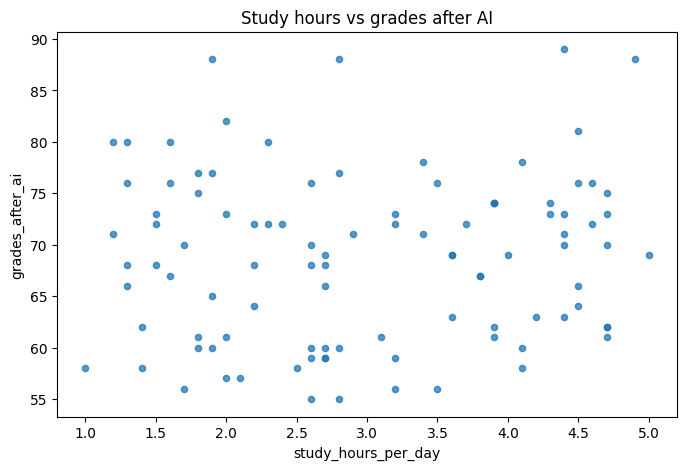

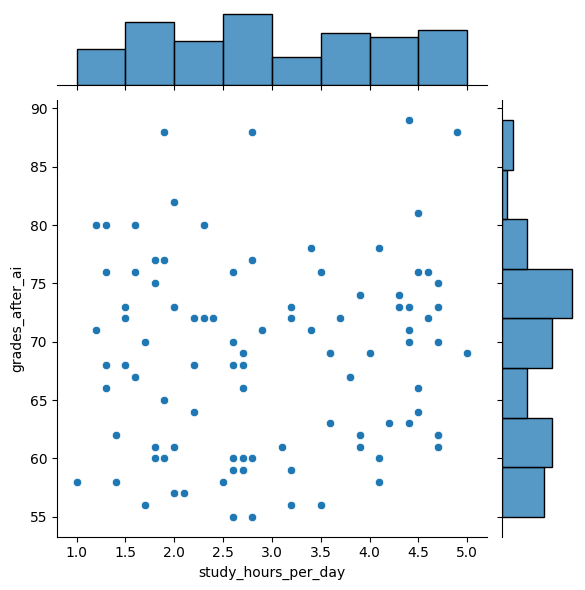

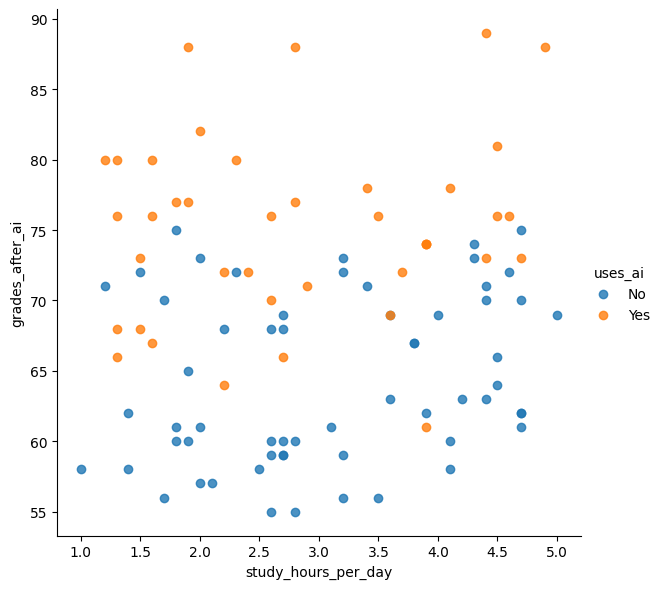

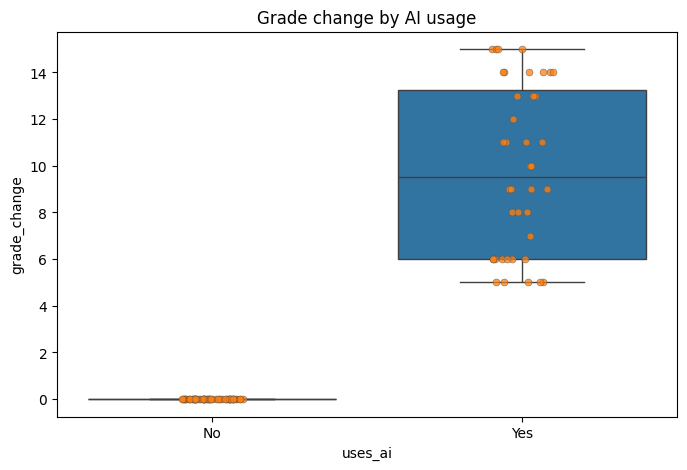

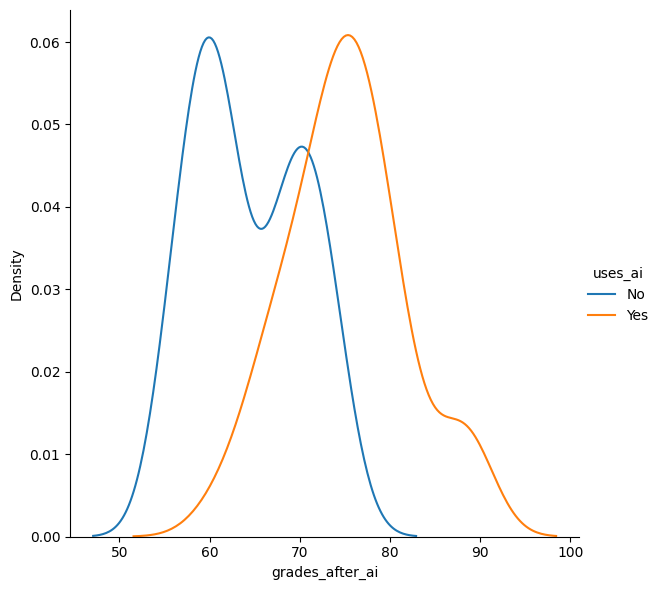

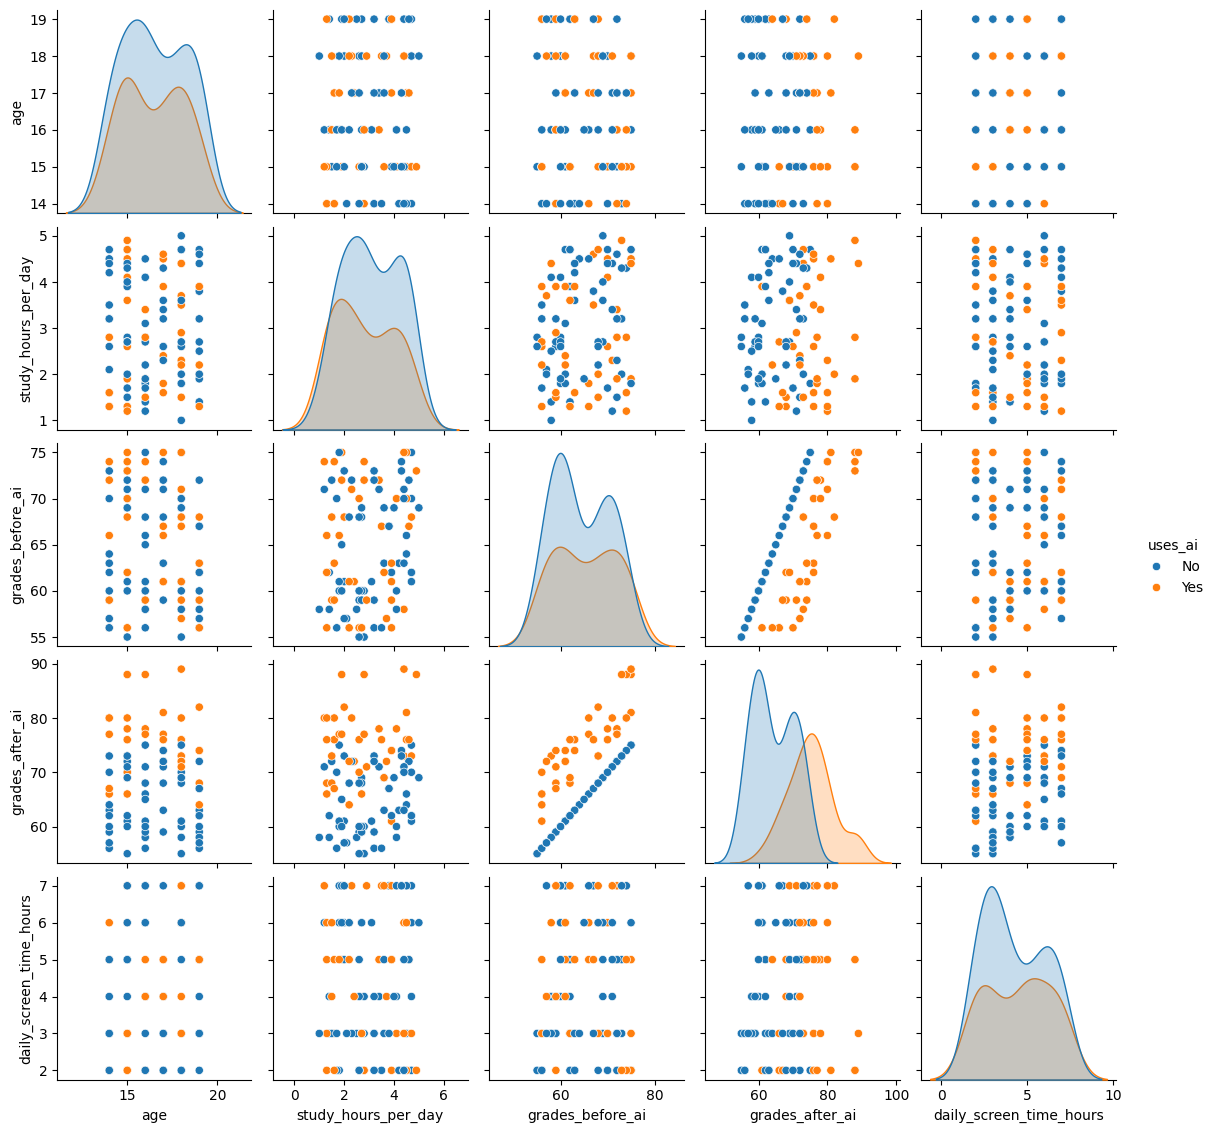

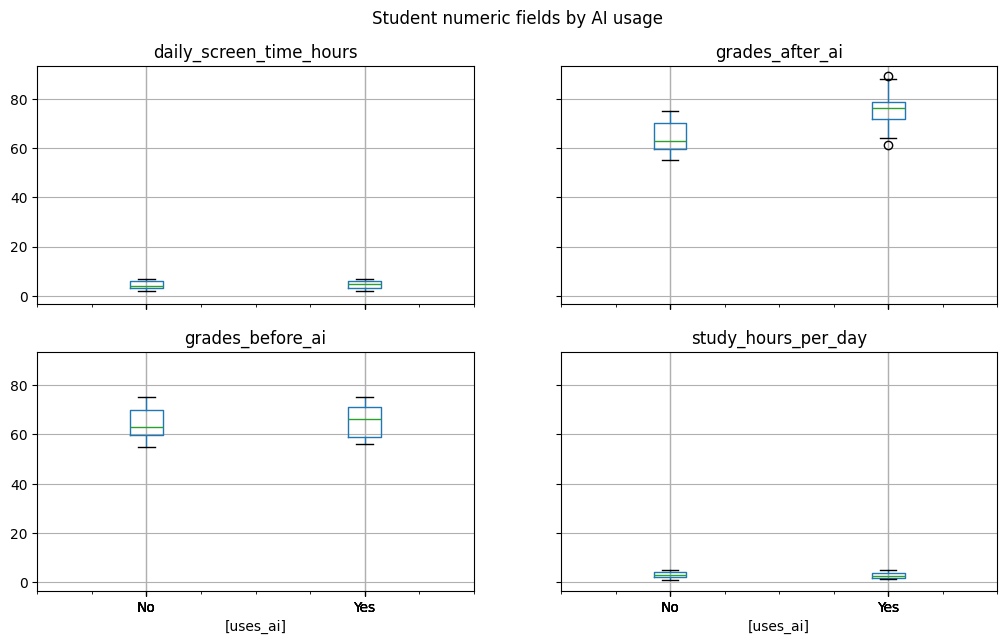

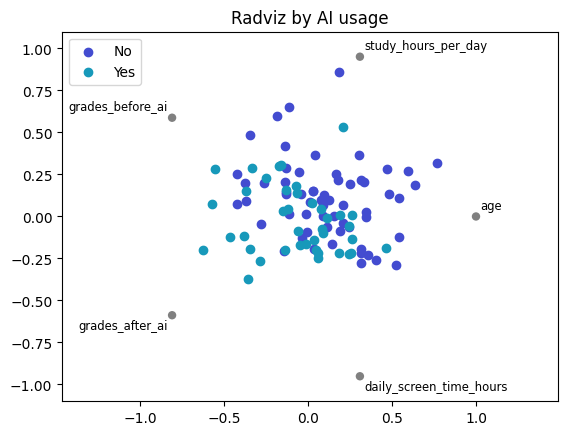

In [7]:
plot_df = data.copy()
plot_df.plot(kind='scatter', x='study_hours_per_day', y='grades_after_ai', alpha=0.75, figsize=(8, 5), title='Study hours vs grades after AI')
plt.show()

sns.jointplot(x='study_hours_per_day', y='grades_after_ai', data=plot_df, height=6)
plt.show()

sns.FacetGrid(plot_df, hue='uses_ai', height=6).map(plt.scatter, 'study_hours_per_day', 'grades_after_ai', alpha=0.8).add_legend()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='uses_ai', y='grade_change', data=plot_df)
sns.stripplot(x='uses_ai', y='grade_change', data=plot_df, jitter=True, edgecolor='gray', linewidth=0.4, alpha=0.75)
plt.title('Grade change by AI usage')
plt.show()

sns.FacetGrid(plot_df, hue='uses_ai', height=6).map(sns.kdeplot, 'grades_after_ai').add_legend()
plt.show()

pair_cols = ['age', 'study_hours_per_day', 'grades_before_ai', 'grades_after_ai', 'daily_screen_time_hours', 'uses_ai']
sns.pairplot(plot_df[pair_cols], hue='uses_ai', height=2.3, diag_kind='kde')
plt.show()

box_cols = ['uses_ai', 'study_hours_per_day', 'grades_before_ai', 'grades_after_ai', 'daily_screen_time_hours']
plot_df[box_cols].boxplot(by='uses_ai', figsize=(12, 7))
plt.suptitle('Student numeric fields by AI usage')
plt.show()

from pandas.plotting import radviz
radviz_cols = ['age', 'study_hours_per_day', 'grades_before_ai', 'grades_after_ai', 'daily_screen_time_hours', 'uses_ai']
radviz(plot_df[radviz_cols], 'uses_ai')
plt.title('Radviz by AI usage')
plt.show()


## What was learned from Lab 2

These plots give an initial view of distributions, category balance, relationships between numeric fields, and possible separation by important labels or groups. No preprocessing or machine learning model is applied yet; that begins from Lab 3 onward.
